### MEMBAHAS 

1. Pernyatan Masalah 
- memahami bagaimana kinerja siswa (nilai ujian) dipengaruhi oleh variabel lain seperti Jenis Kelamin, Etnis, Tingkat Pendidikan Orang Tua, Makan Siang, dan Kursus Persiapan Ujian.

2. Pengumpula Data
- Sumber Dataset - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- Data terdiri dari 8 kolom dan 1000 baris.

3. Informasi Dataset 
- gender: jenis kelamin siswa -> (Laki-laki/perempuan)
- ras/etnis: etnis siswa -> (Kelompok A, B, C, D, E)
- tingkat pendidikan orang tua: pendidikan terakhir orang tua -> (gelar sarjana, beberapa perguruan tinggi, gelar magister, gelar associate, SMA)
- makan siang: makan siang sebelum ujian (standar atau gratis/diskon)
- kursus persiapan ujian: selesai atau tidak selesai sebelum ujian
- skor matematika
- skor membaca
- skor menulis

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape # df.shape — cek dimensi (rows × cols).

(1000, 8)

### 3. Pemeriksaan Data yang akan dilakukan

- Periksa Nilai yang Hilang
- Periksa Duplikat
- Periksa Tipe Data
- Periksa Jumlah Nilai Unik di Setiap Kolom
- Periksa Statistik Kumpulan Data
- Periksa Berbagai Kategori yang Ada di Kolom Kategori yang Berbeda

In [4]:
df.isnull().sum() # check missing value

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [5]:
df.duplicated().sum() # check nilai duplicated

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


nunique() — hitung unique values per kolom. Kolom numerik biasa banyak, kategorikal sedikit.

In [7]:
## 3.1 Menghitung jumlah unik nilai dari setiap kolom
df.nunique() # Menghitung jumlah unik nilai setiap kolom

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [8]:
df.describe() # nilai statistik dataset

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Wawasan atau Observasi

- Dari uraian data numerik di atas, semua rata-rata sangat berdekatan - antara 66 dan 69
- Semua simpangan baku juga berdekatan - antara 14,6-15,19
- Meskipun terdapat nilai minimum 0 untuk matematika, yang lainnya memiliki nilai 17 dan 10

In [9]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
df.tail()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


List comprehension ambil kolom dengan dtype 'O' (object/string).

In [11]:
[feature for feature in df.columns if df[feature].dtype=='O']

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

Pisahin numerical_features & categorical_features dalam 2 list — buat workflow EDA.

In [12]:
# memisahkan kolom kategori dan numerik 
numerical_feature = [feature for feature in df.columns if df[feature].dtype!='O']
kategorikal_feature = [feature for feature in df.columns if df[feature].dtype=='O']

In [13]:
# lihat column numerik ada apa aja 
numerical_feature

['math_score', 'reading_score', 'writing_score']

In [14]:
# nilai kolom kategori ada apa aja 
kategorikal_feature

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

In [15]:
# value_counts() menghitung ada berapa banyak jumalah laki2 & perempuan 
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

# FEATURE ENGINEERING

In [16]:
# bikin kolom total scores (jumlah 3 nilai ) & average nya. lalu di bagi tiga
df['total_scores'] = (df['math_score']+df['reading_score']+df['writing_score'])
df['average'] = df['total_scores']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_scores,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


<Axes: xlabel='average', ylabel='Count'>

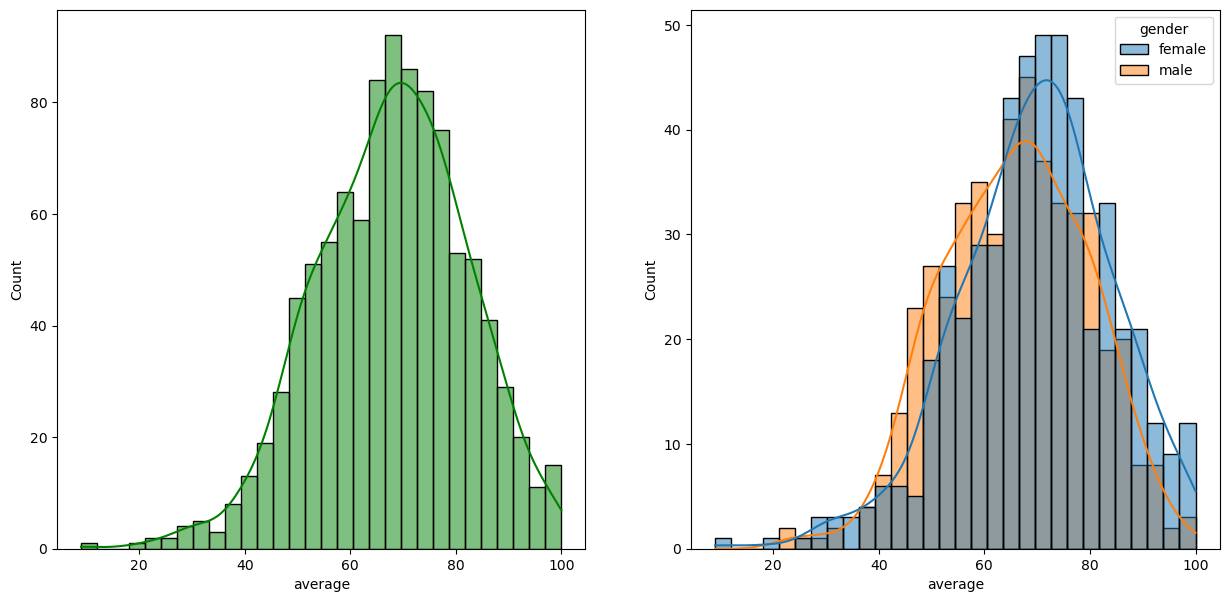

In [17]:
### Eksplorasi Lebih Lanjut Visualisasi
plt.subplots(1,2,figsize=(15,7))
plt.subplot(121) # nyuruh buat bikin grafik untuk (1 baris, 2 kolom, plot ke-1)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122) # nyuruh bikin grafik untuk plot kedua di kanan
sns.histplot(data=df,x='average',bins=30,kde=True,hue='gender')

### wawasan
dari grafik di atas dapat di simpulkan bahwa siswa perempuan lebih pitar daripada siswa laki laki

### 📊 Analisis Pengaruh Fasilitas Makan Siang (*Lunch*) terhadap Performa Akademik Siswa

Pada tahap ini, kita melakukan visualisasi menggunakan **Histogram** dan **KDE (Kernel Density Estimate)** untuk menguji sebuah hipotesis penting: **Apakah jenis makan siang (*lunch*) yang diterima siswa berkorelasi dengan tingkat kecerdasan akademik atau nilai rata-rata (`average`) mereka?**

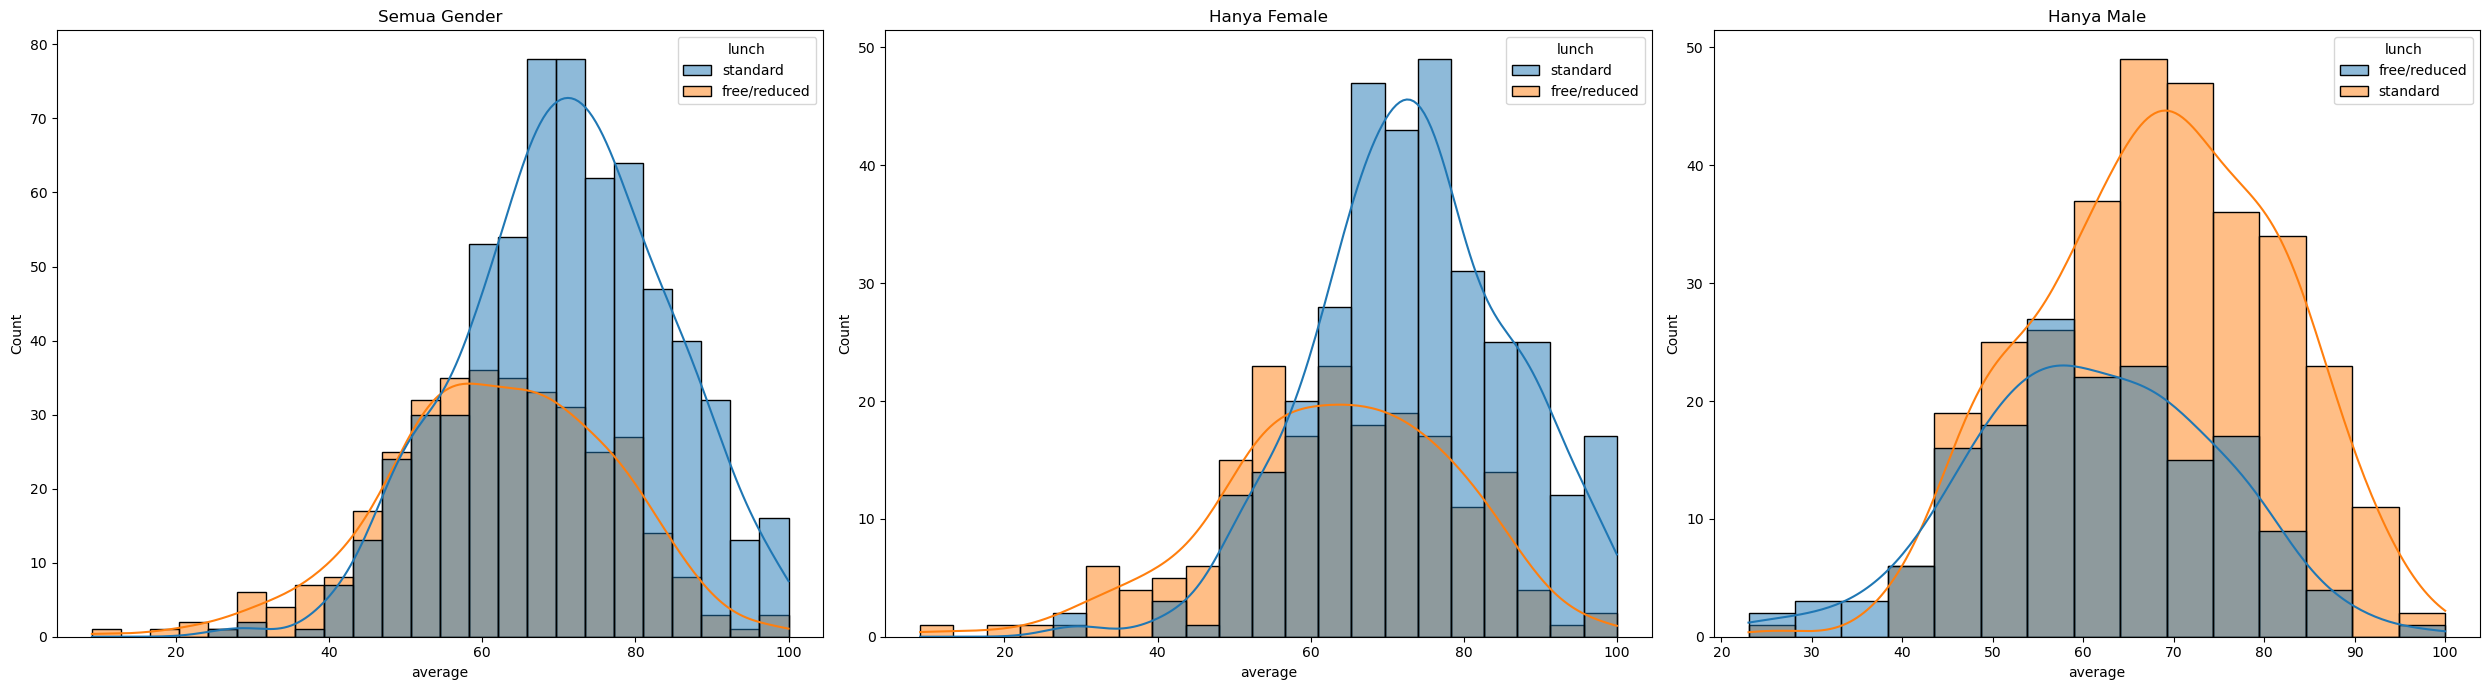

In [18]:
# Subplot 1x3: distribusi rata-rata berdasarkan jenis lunch (overall, female, male). Lihat efek lunch ke performa.

# 1. Siapkan kanvas untuk 1 baris, 3 kolom (Sudah benar 3)
plt.subplots(1, 3, figsize=(25, 7))

# 2. Grafik pertama di kotak nomor 1 dari 3 kolom
plt.subplot(131) 
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.title("Semua Gender")

# 3. Grafik kedua di kotak nomor 2 dari 3 kolom
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='lunch')
plt.title("Hanya Female")

# 4. Grafik ketiga di kotak nomor 3 dari 3 kolom
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='lunch')
plt.title("Hanya Male")

plt.tight_layout()
plt.show()

### Wawasan
- Makan Siang Standar membantu siswa berprestasi baik dalam ujian
- Makan Siang Standar membantu siswa berprestasi baik dalam ujian, baik pria maupun wanita

In [19]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_scores,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


Subplot 1x3: distribusi nilai rata-rata berdasarkan parental_level_of_education (overall, female, male).

Text(0.5, 1.0, 'parental level male')

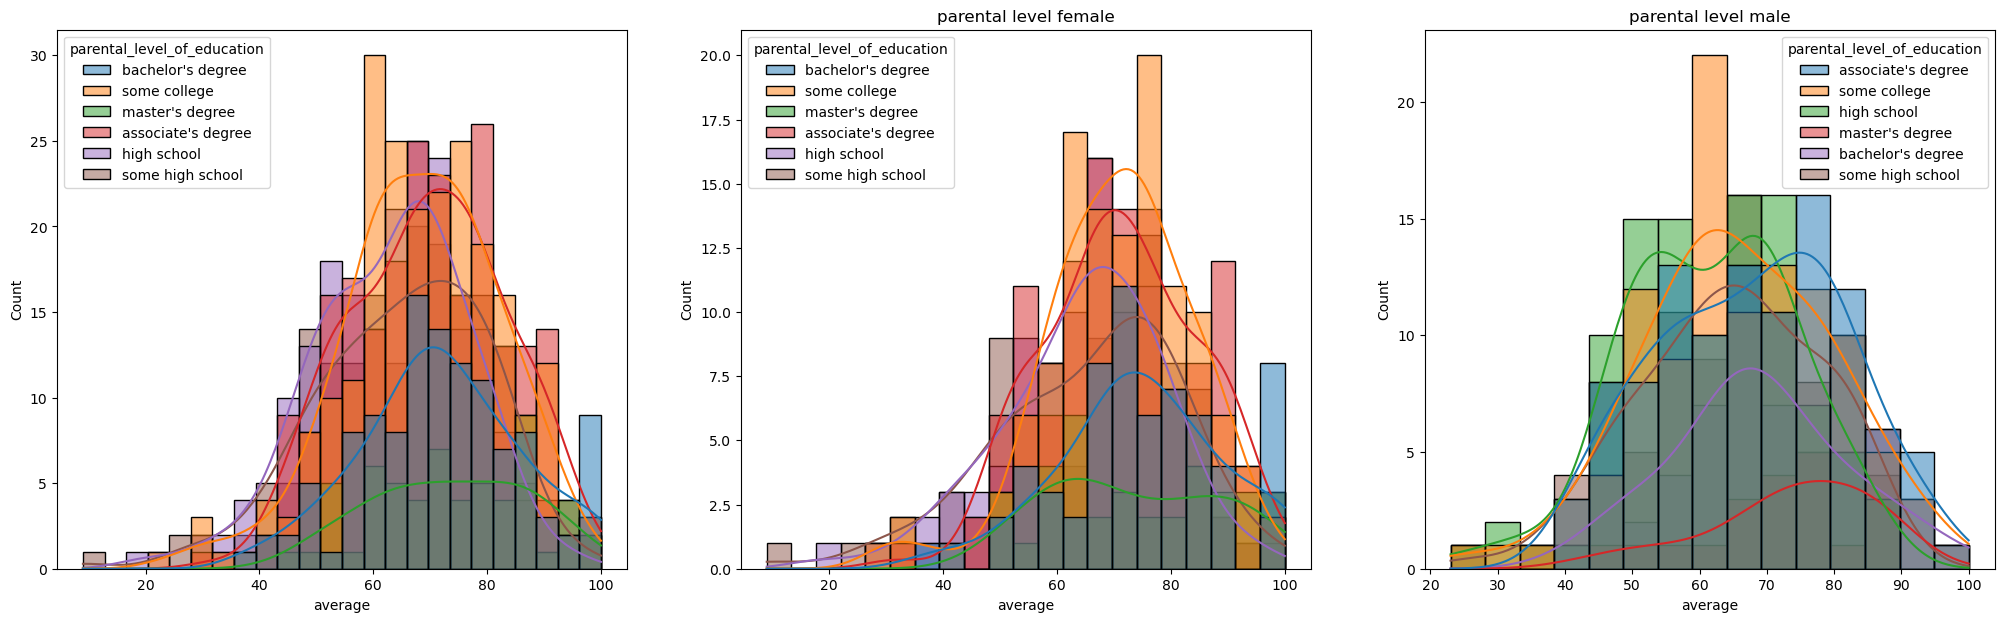

In [20]:
plt.subplots(1,3, figsize =(25,7))
plt.subplot(131)
sns.histplot(data = df, x='average', kde=True, hue='parental_level_of_education')

plt.subplot(132)
sns.histplot(data= df[df.gender=='female'], x='average', kde=True, hue='parental_level_of_education')
plt.title("parental level female")

plt.subplot(133)
sns.histplot(data = df[df.gender=='male'],x='average', kde=True, hue='parental_level_of_education')
plt.title("parental level male")


### wawasan
dari grafik di atas di ketahui bahwa 
- Secara umum, pendidikan orang tua tidak membantu siswa berprestasi baik dalam ujian.
- Grafik ke-3 menunjukkan bahwa orang tua yang berpendidikan D3 atau S2, sementara anak laki-laki mereka cenderung berprestasi baik dalam ujian.
- Grafik ke-2 menunjukkan tidak adanya pengaruh pendidikan orang tua terhadap siswa perempuan.

Text(0.5, 1.0, 'race ethnicity male')

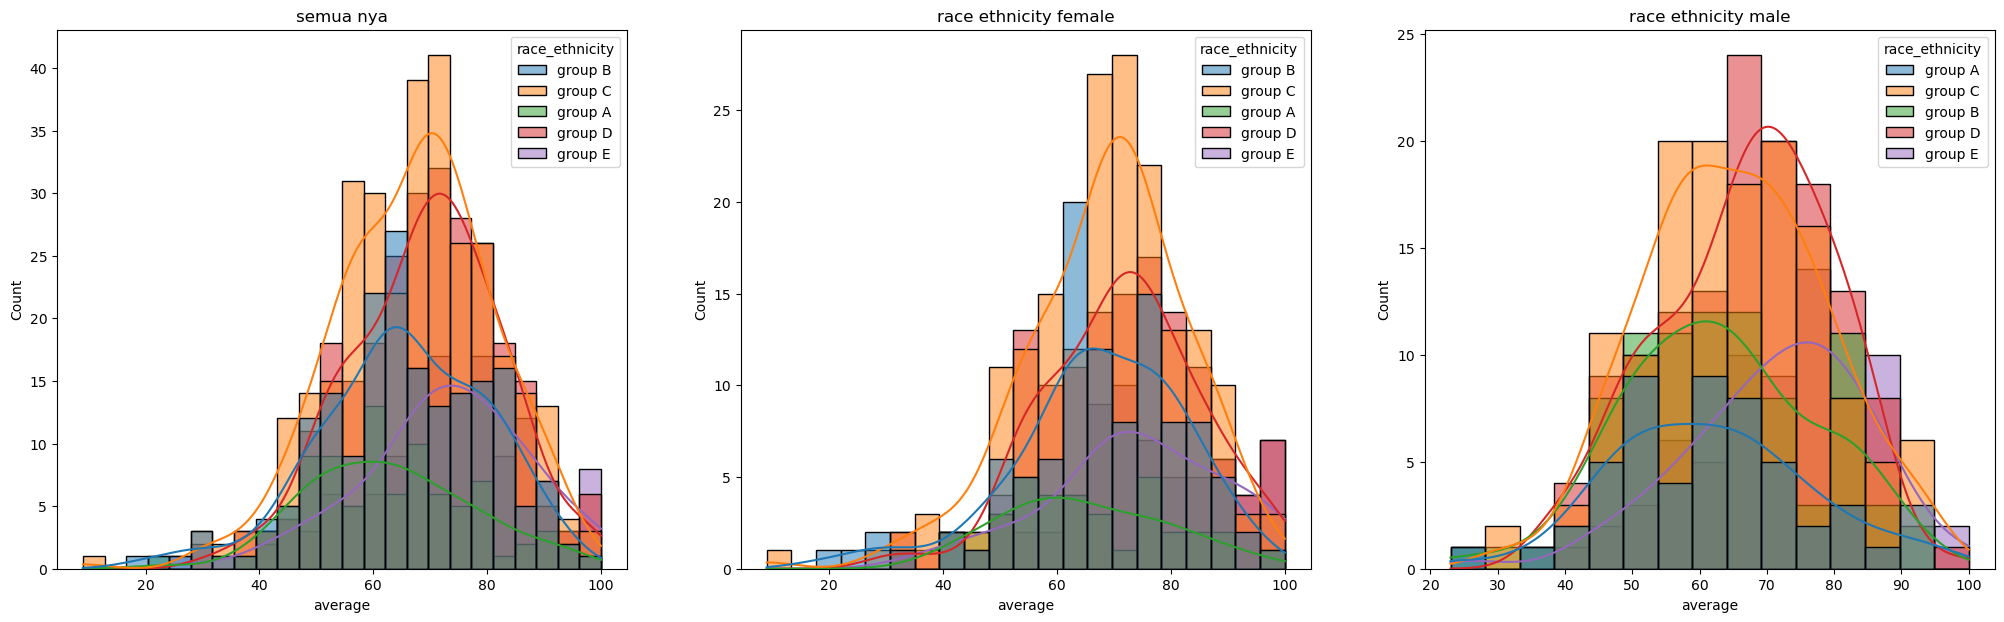

In [22]:
plt.subplots(1,3, figsize=(25,7))
plt.subplot(131)
sns.histplot(data = df, x='average', kde=True, hue='race_ethnicity')
plt.title('semua nya')

plt.subplot(132)
sns.histplot(data= df[df.gender=='female'], x='average', kde=True, hue='race_ethnicity')
plt.title('race ethnicity female')

plt.subplot(133)
sns.histplot(data = df[df.gender=='male'], x='average', kde=True, hue='race_ethnicity')
plt.title('race ethnicity male')

### Wawasan
- Siswa kelompok A dan B cenderung berprestasi buruk dalam ujian.
- Siswa kelompok A dan B cenderung berprestasi buruk dalam ujian, terlepas dari apakah mereka laki-laki atau perempuan.

Heatmap correlation semua kolom numerik dengan annotasi. Lihat fitur mana yg saling berkorelasi.




<Axes: >

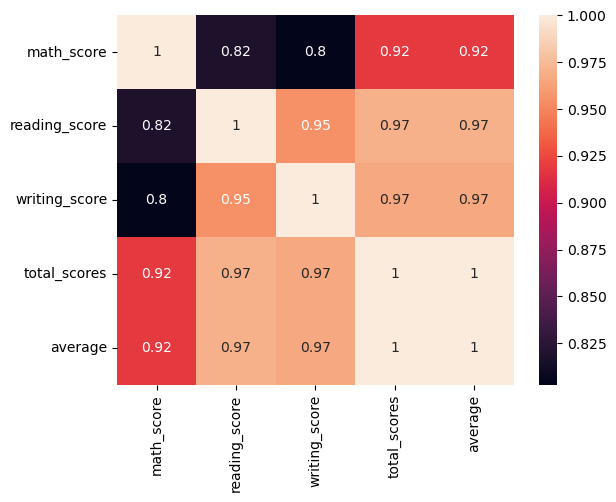

In [33]:
# Tambahkan numeric_only=True di dalam fungsi corr()
sns.heatmap(df.corr(numeric_only=True), annot=True)